In [1]:
import numpy as np 
import sys
import time
import csv
import os
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
import torch
from pathlib import Path
import hydra
from omegaconf import OmegaConf
from datetime import datetime
from tslearn.preprocessing import TimeSeriesScalerMeanVariance

module_path = '/home/cpanourg/projects/2-hdvc/'

if module_path not in sys.path:
    sys.path.append(module_path)

from src.utils import read_fvecs, write_fvecs
from src.utils import append_or_create_csv


# Imports experiments (necessary to register experiments)
from lib.Qinco.qinco.qinco_tasks import QincoConvertTask, QincoEvalTask, QincoTrainTask
from lib.Qinco.qinco.search.search_tasks import (
    BuildIndexTask,
    EncodeDBTask,
    IVFTrainTask,
    SearchTask,
    TrainPairwiseDecoderTask,
)
# from lib.Qinco

2025-11-01 09:53:11.828459: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-01 09:53:12.533976: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761990792.803740 2872845 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761990792.940007 2872845 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761990794.091437 2872845 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [ ]:
root = 'data'
data_fp = f'/{root}/cpanourg/2-hdvc/data/' 
temp_fp = f'/{root}/cpanourg/2-hdvc/temp/' 
results_fp = f'/{root}/cpanourg/2-hdvc/results/'

train_size = 100_000
test_size = 1_000_000

dataset_name = 'deep'

if dataset_name == 'gist':
    db = np.array(read_fvecs(f'{data_fp}gist/gist_base.fvecs')).astype(np.float32)
    qr = np.array(read_fvecs(f'{data_fp}gist/gist_query.fvecs')).astype(np.float32)
    
elif dataset_name == 'deep':
    db = np.fromfile(f'{data_fp}deep1b/dataset/deep1b-96-100m.bin', dtype=np.float32).reshape(100_000_000, -1)
    qr = np.fromfile(f'{data_fp}deep1b/queries/queries-hard10p-deep1b-len96-1000.bin', np.float32).reshape(1000, -1)

idxs = np.random.choice(db.shape[0], train_size + test_size, replace=False)
train_idxs, test_idxs = idxs[:train_size], idxs[train_size:]

train_db, test_db = db[train_idxs], db[test_idxs]

test_db_fp = f'{temp_fp}test_db_set_{dataset_name}.fvecs'
train_db_fp = f'{temp_fp}train_db_set_{dataset_name}.fvecs'
qr_fp = f'{temp_fp}qr_set_{dataset_name}.fvecs'

write_fvecs(train_db_fp, train_db)
write_fvecs(test_db_fp, test_db)
write_fvecs(qr_fp, qr)


nb = test_db.shape[0]  # Number of database vectors
nq = qr.shape[0]  # Number of query vectors
dim = test_db.shape[1]  # Dimensionality of the vectors

print(f"Train db shape: {test_db.shape}")
print(f"Database shape: {test_db.shape}")
print(f"Query shape: {qr.shape}")
print(f"Dimension: {dim}")

dim = test_db.shape[1]
nbits = dim 


Writing File - /data/cpanourg/2-hdvc/temp/train_db_set_deep.fvecs:(100000, 96)
Writing File - /data/cpanourg/2-hdvc/temp/test_db_set_deep.fvecs:(1000000, 96)
Writing File - /data/cpanourg/2-hdvc/temp/qr_set_deep.fvecs:(1000, 96)
Database shape: (1000000, 96)
Query shape: (1000, 96)
Dimension: 96


In [6]:
import numpy as np

def check_znorm(dataset, name="dataset", sample_size=1000):
    """Check approximate z-normalization on a random sample of a large time series dataset."""
    n_sample = min(sample_size, len(dataset))
    idx = np.random.choice(len(dataset), size=n_sample, replace=False)
    X_sample = dataset[idx]

    # Compute per-series mean and std
    means = X_sample.mean(axis=1)
    stds = X_sample.std(axis=1)

    # Aggregate summary stats
    mean_of_means = means.mean()
    mean_of_stds = stds.mean()
    std_of_means = means.std()
    std_of_stds = stds.std()

    print(f"\n{name}")
    print(f"Sampled {n_sample} / {len(dataset)} series")
    print(f"Average mean across sampled series: {mean_of_means:.5f} ± {std_of_means:.5f}")
    print(f"Average std  across sampled series: {mean_of_stds:.5f} ± {std_of_stds:.5f}")

    return mean_of_means, mean_of_stds


check_znorm(train_db, name="train db", sample_size=10000)
check_znorm(test_db, name="test db", sample_size=10000)
check_znorm(qr, name="queries", sample_size=10000)



train db
Sampled 10000 / 100000 series
Average mean across sampled series: -0.00000 ± 0.00000
Average std  across sampled series: 1.00000 ± 0.00000

test db
Sampled 10000 / 1000000 series
Average mean across sampled series: -0.00000 ± 0.00000
Average std  across sampled series: 1.00000 ± 0.00000

queries
Sampled 1000 / 1000 series
Average mean across sampled series: -0.00152 ± 0.03305
Average std  across sampled series: 0.32887 ± 0.02251


(-0.0015182296, 0.3288682)

In [7]:

scaler = TimeSeriesScalerMeanVariance(mu=0.0, std=1.0)
test_db = scaler.fit_transform(test_db).squeeze()
train_db = scaler.fit_transform(train_db).squeeze()
qr = scaler.fit_transform(qr).squeeze()


check_znorm(train_db, name="train db", sample_size=10000)
check_znorm(test_db, name="test db", sample_size=10000)
check_znorm(qr, name="queries", sample_size=10000)


/home/cpanourg/.miniconda3/envs/dtwrl_env2/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/cpanourg/.miniconda3/envs/dtwrl_env2/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/cpanourg/.miniconda3/envs/dtwrl_env2/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/cpanourg/.miniconda3/envs/dtwrl_env2/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



train db
Sampled 10000 / 100000 series
Average mean across sampled series: -0.00000 ± 0.00000
Average std  across sampled series: 1.00000 ± 0.00000

test db
Sampled 10000 / 1000000 series
Average mean across sampled series: 0.00000 ± 0.00000
Average std  across sampled series: 1.00000 ± 0.00000

queries
Sampled 1000 / 1000 series
Average mean across sampled series: -0.00000 ± 0.00000
Average std  across sampled series: 1.00000 ± 0.00000


/home/cpanourg/.miniconda3/envs/dtwrl_env2/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/cpanourg/.miniconda3/envs/dtwrl_env2/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(-4.4177624521542685e-19, 1.0)

In [8]:
val_ratio = 0.1     # portion for validation

# --- Compute split indices ---
n_train = len(train_db)
n_val = int(val_ratio * n_train)
n_test = len(test_db)  # ensures total matches exactly

# --- Slice into splits ---
train_set = train_db
val_set = db[n_train:n_train + n_val]
test_set = test_db

# --- Display summary ---
print(f"Train set size: {len(train_set)}")
print(f"Validation set size: {len(val_set)}")
print(f"Test set size: {len(test_set)}")

train_val_set_fp = f"{temp_fp}{dataset_name}_val_ratio{val_ratio}.fvecs"
write_fvecs(train_val_set_fp, np.concatenate([train_set,val_set]))


Train set size: 100000
Validation set size: 10000
Test set size: 1000000
Writing File - /data/cpanourg/2-hdvc/temp/deep_val_ratio0.1.fvecs:(110000, 96)


In [11]:

cfg = OmegaConf.load("/home/cpanourg/projects/2-hdvc/lib/Qinco/config/qinco_cfg.yaml")


EXPERIMENTS = {
    "train": QincoTrainTask,
    "eval_valset": QincoTrainTask,
    "eval": QincoEvalTask,
    "eval_time": QincoEvalTask,
    "convert": QincoConvertTask,
    "ivf_centroids": IVFTrainTask,
    "encode": EncodeDBTask,
    "build_index": BuildIndexTask,
    "train_pairwise_decoder": TrainPairwiseDecoderTask,
    "search": SearchTask,
}


# Get current datetime
now = datetime.now()

# Format as string: year_month_day_hour_minute_second
datetime_str = now.strftime("%Y_%m_%d_%H_%M_%S")

print(datetime_str)


cfg.task = 'train'
cfg.output = f'/{root}/cpanourg/2-hdvc/results/qinco2/qinco_weights_{datetime_str}.pt'

# cfg.L = 16 # num of resblocks in each step
# cfg.dh = 384

# # ----------------------------------------------------------------
# # these values can be set as 0 to disable these components 
# cfg.de = 384 # embedding dimension (if 0 dimension is the same as data)
# cfg.A = 16 # num of fast pre-selected candidates (if 0 no beam search)
# cfg.B = 32 # size of beam search (if 0 then no pre-selected candidates) 
# # ----------------------------------------------------------------

# cfg.M = 8 # number of codebooks
# cfg.K = 256 # codebook size 
# cfg.ivf_K = 1048576

# cfg.epochs = 70 # note that it runs along with the patience (=10 by default)

cfg.L = 16        # paper default
cfg.dh = 384      # paper default
cfg.de = 384      # paper default
cfg.M = 8         # paper default
cfg.K = 256       # paper default
cfg.A = 16        # paper default
cfg.B = 32        # paper default
cfg.ivf_K = 1048576  # paper default (1M centroids)
cfg.epochs = 70   # paper default
cfg.optimizer = "adamw"
cfg.lr = 8e-4
cfg.wd = 0.1
cfg.grad_clip = 0.1
cfg.batch = 1024

cfg.db = test_db_fp
cfg.trainset = train_val_set_fp 
cfg.ds.valset = n_val

expe = EXPERIMENTS[cfg.task](cfg)


2025_11_01_10_07_25


In [14]:
load_model = True

if load_model:
    checkpoint_model = torch.load('/data/cpanourg/2-hdvc/results/qinco2/qinco_weights_2025_10_26_16_15_57.pt')
    expe.qinco_model.load_state_dict(checkpoint_model['model'])

else:
    expe.accelerator.print(f"====================== RUNNING TASK {cfg.task}")
    expe.run()
    expe.accelerator.print("Task done")
    expe.accelerator.end_training()  # Destroy process group


In [15]:
expe.qinco_model.eval()

QINCo(
  (steps): ModuleList(
    (0): QINCoStep(
      (codebook): Embedding(256, 96)
    )
    (1-7): 7 x QINCoStep(
      (substep): QincoSubstep(
        (codebook): Embedding(256, 96)
      )
      (codebook): Embedding(256, 96)
      (concat): RecursiveScriptModule(
        original_name=QConcat
        (mlp): RecursiveScriptModule(original_name=Linear)
      )
      (residual_blocks): RecursiveScriptModule(
        original_name=Sequential
        (0): RecursiveScriptModule(
          original_name=QBlockFFN
          (up_proj): RecursiveScriptModule(original_name=Linear)
          (act): RecursiveScriptModule(original_name=ReLU)
          (down_proj): RecursiveScriptModule(original_name=Linear)
        )
        (1): RecursiveScriptModule(
          original_name=QBlockFFN
          (up_proj): RecursiveScriptModule(original_name=Linear)
          (act): RecursiveScriptModule(original_name=ReLU)
          (down_proj): RecursiveScriptModule(original_name=Linear)
        )
       

In [16]:
sample_queries=1000
sample_db=10000

q_idx = np.random.choice(nq, min(sample_queries, nq), replace=False)
db_idx = np.random.choice(nb, min(sample_db, nb), replace=False)

qr_sample = qr[q_idx]
db_sample = db[db_idx]

In [17]:
# Exact distances with cdist
t0 = time.time()
exact_dists = cdist(qr_sample, db_sample, metric="sqeuclidean").astype(np.float32)
cdist_time = time.time() - t0


In [18]:
db_torch = torch.tensor(db_sample).to('cuda')
qr_torch = torch.tensor(qr_sample).to('cuda')

In [23]:
db_torch.shape, qr_torch.shape

(torch.Size([10000, 96]), torch.Size([1000, 96]))

In [32]:
with torch.no_grad():
    db_codes = expe.qinco_model.encode(db_torch)
db_codes.shape

AttributeError: 'tuple' object has no attribute 'shape'

In [27]:
db_codes

(tensor([[232, 146, 131,  ...,  65, 107,  91],
         [ 26,  26,  26,  ...,  26,  26,  26],
         [ 90,  90,  90,  ...,  90,  90,  90],
         ...,
         [122, 122, 122,  ..., 122, 122, 122],
         [244, 244, 244,  ..., 244, 244, 244],
         [ 26, 246, 240,  ...,  26, 246, 246]], device='cuda:0'),
 tensor([[ 0.0043, -0.6888, -0.8282,  ..., -0.9655,  1.1319, -1.0859],
         [-0.0140, -0.5324,  0.6869,  ...,  0.8492,  0.4899, -0.2912],
         [-0.6410, -0.2512,  0.0398,  ..., -0.7972, -0.6200,  0.2698],
         ...,
         [ 0.3832,  1.0448, -0.2308,  ...,  0.6200, -0.7525, -0.1595],
         [ 0.7610,  2.5515, -0.4792,  ...,  0.2486, -1.3285, -0.5845],
         [ 0.4613, -0.0302,  0.6046,  ..., -0.6817,  0.7470, -0.1825]],
        device='cuda:0'))

In [ ]:
cfg.

In [ ]:
codebooks = expe.qinco_model.codebooks  # list or tensor of shape (M, K, Dsub)
sub_queries = qr_torch.view(M, Dsub)

lookup_tables = torch.stack([
    ((sq.unsqueeze(0) - cb)**2).sum(dim=1)  # L2 distance
    for sq, cb in zip(sub_queries, codebooks)
])


AttributeError: 'QINCo' object has no attribute 'compute_distance_table'

## Exact (decoded) Distances

In [25]:
qr_dec = qr_codes[1]
db_dec = db_codes[1]

qr_dec.shape, db_dec.shape

(torch.Size([1000, 96]), torch.Size([10000, 96]))

In [34]:
t0 = time.time()
rec_dists = cdist(qr_dec.cpu().numpy(), db_dec.cpu().numpy(), metric="sqeuclidean").astype(np.float32)
rec_dists_time = time.time() - t0

In [36]:
exact_dists

array([[101.6091 , 109.83041, 106.57764, ..., 105.42566, 116.17758,
        107.05952],
       [ 98.46004,  97.57552, 114.64189, ..., 101.29948,  95.61234,
        105.31535],
       [104.49021, 101.02367,  97.16537, ..., 117.09985, 104.99667,
        100.22083],
       ...,
       [ 97.84881, 107.76525, 110.83449, ..., 109.31743, 112.37376,
        105.28899],
       [108.14077, 107.45512, 104.61993, ..., 102.74899, 105.55005,
        109.97344],
       [102.19077, 110.65828, 109.75002, ..., 118.3119 , 111.79379,
        105.05746]], dtype=float32)

In [35]:
rec_dists

array([[ 86.81232, 118.12766, 107.02308, ..., 104.80472, 103.43365,
         78.44249],
       [ 74.97477, 101.7181 , 106.50413, ..., 107.55148,  90.11442,
         81.49905],
       [ 80.03765, 105.29258,  83.54477, ..., 128.8048 , 101.03614,
         74.79919],
       ...,
       [ 72.64948, 115.36543, 109.43454, ..., 117.91432, 103.0806 ,
         77.77961],
       [ 89.29108, 115.98496,  87.07746, ..., 105.5178 , 110.9217 ,
         83.76535],
       [ 89.32549, 111.04539,  94.68987, ..., 114.26163, 108.79827,
         75.02436]], dtype=float32)

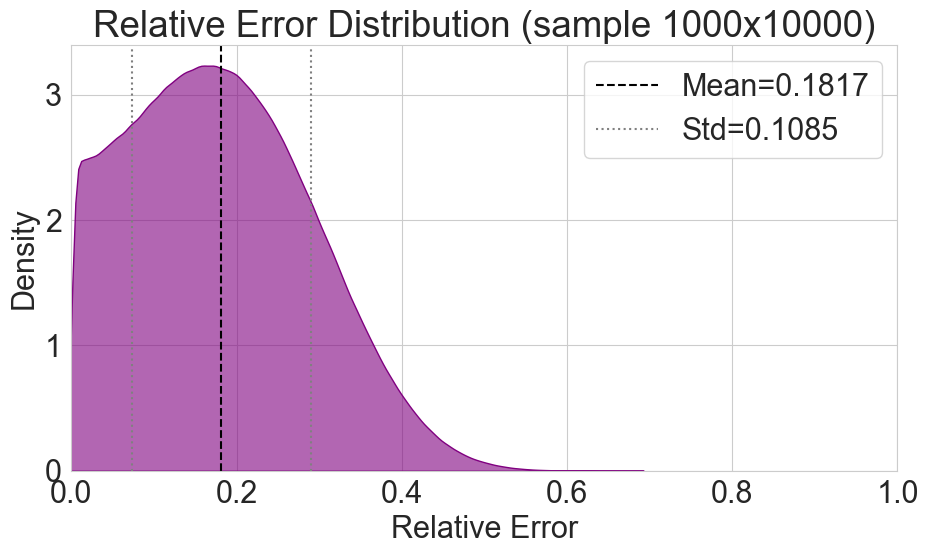

[cdist] sample 1000 queries x 10000 DB: 0.557s
Mean relative error=0.181687, Std=0.108516


In [40]:
import matplotlib.pyplot as plt 
import seaborn as sns 

plt.rcParams['font.family'] = 'serif'
sns.set_style("whitegrid")
# Relative errors
rel_error = np.abs(rec_dists - exact_dists) / (exact_dists + 1e-12)
rel_error.astype(np.float32).tofile(f'{results_fp}qinco2/rel_error_rec.bin')
mean_rel, std_rel = rel_error.mean(), rel_error.std()

# Plot KDE of relative errors
rel_error_flat = rel_error.ravel()
plt.figure(figsize=(10, 6))
plt.xlim(0, 1)
sns.kdeplot(rel_error_flat, fill=True, color="purple", alpha=0.6)
plt.axvline(mean_rel, linestyle="--", color="black", label=f"Mean={mean_rel:.4f}")
plt.axvline(mean_rel-std_rel, linestyle=":", color="grey")
plt.axvline(mean_rel+std_rel, linestyle=":", color="grey", label=f"Std={std_rel:.4f}")
plt.title(f"Relative Error Distribution (sample {len(q_idx)}x{len(db_idx)})")
plt.xlabel("Relative Error")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

print(f"[cdist] sample {len(q_idx)} queries x {len(db_idx)} DB: {cdist_time:.3f}s")
print(f"Mean relative error={mean_rel:.6f}, Std={std_rel:.6f}")


## Approximate Distances in the Compressed Domain 

In [58]:
import re, torch

# qr_dec must be (N_q, D) torch tensor on CPU
qr_dec = qr_dec.detach().cpu() if isinstance(qr_dec, torch.Tensor) else torch.tensor(qr_dec, dtype=torch.float32)

# get state dict (prefer in-memory model, fallback to checkpoint)
m = getattr(expe.qinco_model, "module", expe.qinco_model)
sd = None
try:
    sd = m.state_dict()
except Exception:
    ckpt_path = getattr(cfg, "output", None)
    if ckpt_path:
        ckpt = torch.load(ckpt_path, map_location="cpu")
        sd = ckpt.get("state_dict", ckpt)

if sd is None:
    raise RuntimeError("No state_dict found in model or checkpoint")

# find codebook keys grouped by step index
pattern = re.compile(r"steps\.(\d+)\.(?:substep\.)?codebook\.weight")
groups = {}
for k in sd.keys():
    mm = pattern.match(k)
    if mm:
        idx = int(mm.group(1))
        groups.setdefault(idx, []).append(k)

# number of expected steps (fallback to max found +1)
M_expected = getattr(cfg, "M", max(groups.keys())+1 if groups else 0)

codebooks = []
for i in range(M_expected):
    main_key = f"steps.{i}.codebook.weight"
    sub_key = f"steps.{i}.substep.codebook.weight"
    chosen_key = None
    if main_key in sd:
        chosen_key = main_key
    elif sub_key in sd:
        chosen_key = sub_key
    elif i in groups and len(groups[i])>0:
        chosen_key = groups[i][0]
    if chosen_key is None:
        print(f"warning: no codebook found for step {i}, skipping")
        continue
    wt = torch.as_tensor(sd[chosen_key]).detach().cpu().float().clone()
    # ensure shape is (K, D). if stored transposed, fix it.
    if wt.ndim == 2 and wt.shape[1] == qr_dec.shape[1]:
        # (K, D) good
        cb = wt
    elif wt.ndim == 2 and wt.shape[0] == qr_dec.shape[1]:
        cb = wt.t().contiguous()
    else:
        raise RuntimeError(f"codebook {chosen_key} has incompatible shape {tuple(wt.shape)} vs qr D={qr_dec.shape[1]}")
    codebooks.append(cb)

print(f"Selected {len(codebooks)} codebooks; shapes: {[tuple(cb.shape) for cb in codebooks]}")

# compute lookup tables: each is (N_q, K) with squared euclidean distances
lookup_tables = [torch.cdist(qr_dec, cb, p=2) ** 2 for cb in codebooks]
print("lookup table shapes:", [lt.shape for lt in lookup_tables])

Selected 8 codebooks; shapes: [(256, 96), (256, 96), (256, 96), (256, 96), (256, 96), (256, 96), (256, 96), (256, 96)]
lookup table shapes: [torch.Size([1000, 256]), torch.Size([1000, 256]), torch.Size([1000, 256]), torch.Size([1000, 256]), torch.Size([1000, 256]), torch.Size([1000, 256]), torch.Size([1000, 256]), torch.Size([1000, 256])]


In [62]:

from numba import njit, prange

@njit(parallel=True, fastmath=True)
def adc_distances_batch_numba(dis_tables_q, db_codes, M):
    # dis_tables_q: (nq, M, K) float32
    # db_codes: (nb, M) int64 (indices 0..K-1)
    nq = dis_tables_q.shape[0]
    nb = db_codes.shape[0]
    out = np.empty((nq, nb), dtype=np.float32)
    for i in prange(nq):
        for j in range(nb):
            s = 0.0
            for m in range(M):
                idx = db_codes[j, m]
                s += dis_tables_q[i, m, idx]
            out[i, j] = s
    return out
# --- convert qr_codes -> per_step_qr (list of (N_q, D) numpy float32) ---
qr_enc = qr_codes  # whatever you obtained from expe.qinco_model.encode(...)
per_step_qr = None
if isinstance(qr_enc, (tuple, list)):
    if len(qr_enc) > 2 and isinstance(qr_enc[2], (list, tuple)):
        per_step_qr = [t.detach().cpu().numpy().astype(np.float32) if hasattr(t, "detach") else np.asarray(t, dtype=np.float32)
                       for t in qr_enc[2]]
    elif len(qr_enc) > 1 and hasattr(qr_enc[1], "detach"):
        final_qr = qr_enc[1].detach().cpu().numpy().astype(np.float32)
        per_step_qr = [final_qr for _ in range(len(codebooks))]
    else:
        final_qr = np.asarray(qr_enc[1], dtype=np.float32) if len(qr_enc) > 1 else np.asarray(qr_enc[0], dtype=np.float32)
        per_step_qr = [final_qr for _ in range(len(codebooks))]
else:
    final_qr = qr_enc.detach().cpu().numpy().astype(np.float32) if hasattr(qr_enc, "detach") else np.asarray(qr_enc, dtype=np.float32)
    per_step_qr = [final_qr for _ in range(len(codebooks))]

# --- convert codebooks list of (K,D) -> numpy float32 ---
codebooks_np = [cb.detach().cpu().numpy().astype(np.float32) if hasattr(cb, "detach") else np.asarray(cb, dtype=np.float32)
                for cb in codebooks]

# build dis_tables (nq, M, K) using vectorized dot-products
nq = per_step_qr[0].shape[0]
M = len(codebooks_np)
K = codebooks_np[0].shape[0]
dis_tables = np.empty((nq, M, K), dtype=np.float32)

for m in range(M):
    qrm = per_step_qr[m]  # (N_q, D) numpy
    cb = codebooks_np[m]  # (K, D) numpy
    # squared norms
    q_norm2 = np.sum(qrm * qrm, axis=1).reshape(-1, 1)        # (N_q, 1)
    cb_norm2 = np.sum(cb * cb, axis=1).reshape(1, -1)        # (1, K)
    # dot product
    prod = np.dot(qrm, cb.T)                                 # (N_q, K)
    # squared euclidean distances
    lt = q_norm2 + cb_norm2 - 2.0 * prod
    # numerical safety
    lt = np.maximum(lt, 0.0).astype(np.float32)
    dis_tables[:, m, :] = lt

# --- prepare DB codes matrix as integer indices (nb_sample, M) ---
def prepare_codes_matrix(codes, M):
    a = np.asarray(codes)
    if a.ndim == 2 and a.shape[1] == M:
        return a.astype(np.int64)
    if a.ndim == 2 and a.dtype == np.uint8 and a.shape[1] >= M:
        return a[:, :M].astype(np.int64)
    raise ValueError(f"Unexpected codes shape/dtype: {a.shape}, {a.dtype}")

codes_sub = prepare_codes_matrix(db_codes[0].reshape(sample_db,-1).cpu().numpy(), M)  # db_codes = db_codes from encode (sample)
# run ADC (numba function defined previously)
adc_dists = adc_distances_batch_numba(dis_tables[q_idx].astype(np.float32), codes_sub, M)
print("adc_sample.shape:", adc_dists.shape)

adc_sample.shape: (1000, 10000)


In [65]:
exact_dists

array([[101.6091 , 109.83041, 106.57764, ..., 105.42566, 116.17758,
        107.05952],
       [ 98.46004,  97.57552, 114.64189, ..., 101.29948,  95.61234,
        105.31535],
       [104.49021, 101.02367,  97.16537, ..., 117.09985, 104.99667,
        100.22083],
       ...,
       [ 97.84881, 107.76525, 110.83449, ..., 109.31743, 112.37376,
        105.28899],
       [108.14077, 107.45512, 104.61993, ..., 102.74899, 105.55005,
        109.97344],
       [102.19077, 110.65828, 109.75002, ..., 118.3119 , 111.79379,
        105.05746]], dtype=float32)

In [64]:
adc_dists

array([[146.26584, 147.64783, 184.07446, ..., 140.91518, 142.32475,
        152.8074 ],
       [149.36182, 150.90018, 171.42038, ..., 146.31956, 146.30759,
        130.95341],
       [157.1274 , 132.04953, 173.0479 , ..., 139.71722, 150.76773,
        141.07764],
       ...,
       [158.51297, 176.22   , 190.79866, ..., 148.21127, 145.3228 ,
        167.6935 ],
       [157.50462, 175.48479, 181.50441, ..., 151.48271, 146.83345,
        157.68018],
       [153.78198, 166.54953, 184.7406 , ..., 148.70212, 158.9358 ,
        157.6329 ]], dtype=float32)

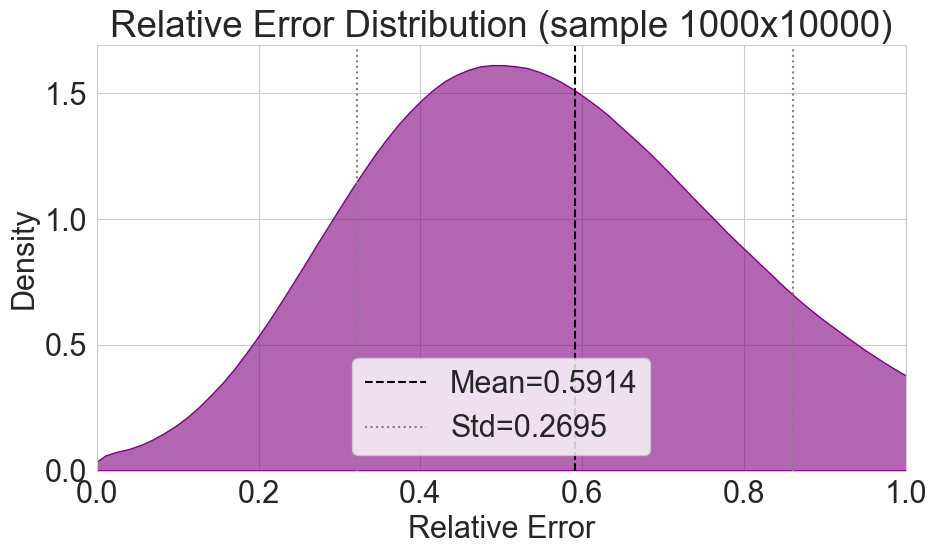

[cdist] sample 1000 queries x 10000 DB: 0.557s
Mean relative error=0.591427, Std=0.269472


In [66]:
import matplotlib.pyplot as plt 
import seaborn as sns 

plt.rcParams['font.family'] = 'serif'
sns.set_style("whitegrid")
# Relative errors
rel_error = np.abs(adc_dists - exact_dists) / (exact_dists + 1e-12)
rel_error.astype(np.float32).tofile(f'{results_fp}qinco2/rel_error_comp.bin')
mean_rel, std_rel = rel_error.mean(), rel_error.std()

# Plot KDE of relative errors
rel_error_flat = rel_error.ravel()
plt.figure(figsize=(10, 6))
plt.xlim(0, 1)
sns.kdeplot(rel_error_flat, fill=True, color="purple", alpha=0.6)
plt.axvline(mean_rel, linestyle="--", color="black", label=f"Mean={mean_rel:.4f}")
plt.axvline(mean_rel-std_rel, linestyle=":", color="grey")
plt.axvline(mean_rel+std_rel, linestyle=":", color="grey", label=f"Std={std_rel:.4f}")
plt.title(f"Relative Error Distribution (sample {len(q_idx)}x{len(db_idx)})")
plt.xlabel("Relative Error")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

print(f"[cdist] sample {len(q_idx)} queries x {len(db_idx)} DB: {cdist_time:.3f}s")
print(f"Mean relative error={mean_rel:.6f}, Std={std_rel:.6f}")


## Pairwise decoder

In [70]:
Nq = 1000
Nb = 10000
M = len(codebooks)       # e.g. 8
K = codebooks[0].shape[0]


In [ ]:
import torch

# Collect per-step codebooks
codebooks = [sd[k].detach().cpu().float() for k in sd if k.endswith(".codebook.weight")]
M = len(codebooks)
K, D = codebooks[0].shape
print(f"Found {M} codebooks of shape ({K}, {D})")

# Define valid pairs
pairs = [(m, m+1) for m in range(0, M-1, 2)]
print("Using pairs:", pairs)

pair_codebooks = []
for (m, n) in pairs:
    C_m, C_n = codebooks[m], codebooks[n]  # each (K, D)
    # Synthetic pairwise codebook (K², D)
    C_pair = (C_m[:, None, :] + C_n[None, :, :]).reshape(K*K, D)
    pair_codebooks.append(C_pair)

print(f"Built {len(pair_codebooks)} pairwise codebooks; each of shape ({K*K}, {D})")

# qr_dec should be [N_q, D]
N_q = qr_dec.shape[0]
pair_dis_tables = []

for Cpair in pair_codebooks:
    # (K^2, D)
    dist = torch.cdist(qr_dec, Cpair, p=2)**2  # [N_q, K^2]
    pair_dis_tables.append(dist)
    print(f"Built lookup table for one pair: {tuple(dist.shape)}")


db_idx = db_codes[0].cpu().numpy().astype(np.int64)  # shape (Nb, M)
pair_indices = [db_idx[:, m] * K + db_idx[:, n] for (m, n) in pairs]
print(f"Built {len(pair_indices)} index arrays; each shape = {pair_indices[0].shape}")

from numba import njit, prange

@njit(parallel=True, fastmath=True)
def adc_pairwise_batch(dis_tables, pair_indices):
    nq = dis_tables[0].shape[0]
    nb = pair_indices[0].shape[0]
    n_pairs = len(dis_tables)
    out = np.empty((nq, nb), np.float32)
    for i in prange(nq):
        for j in range(nb):
            s = 0.0
            for p in range(n_pairs):
                idx = pair_indices[p][j]
                s += dis_tables[p][i, idx]
            out[i, j] = s
    return out

# Convert to numpy float32 for Numba
pair_dis_tables_np = [d.detach().cpu().numpy().astype(np.float32) for d in pair_dis_tables]
adc_pair_dists = adc_pairwise_batch(pair_dis_tables_np, pair_indices)

print("adc_pair_dists.shape:", adc_pair_dists.shape)


Found 15 codebooks of shape (256, 96)
Using pairs: [(0, 1), (2, 3), (4, 5), (6, 7), (8, 9), (10, 11), (12, 13)]
Built 7 pairwise codebooks; each of shape (65536, 96)


Built lookup table for one pair: (1000, 65536)
Built lookup table for one pair: (1000, 65536)
Built lookup table for one pair: (1000, 65536)
Built lookup table for one pair: (1000, 65536)
Built lookup table for one pair: (1000, 65536)
Built lookup table for one pair: (1000, 65536)
Built lookup table for one pair: (1000, 65536)


Built 7 index arrays; each shape = (8,)


In [101]:
len(codebooks)

15

In [102]:
import torch, numpy as np
from numba import njit, prange

# ============================================================
# 1. Collect all per-step codebooks from the state_dict
# ============================================================
codebooks = [sd[k].detach().cpu().float() for k in sd if k.endswith(".codebook.weight")]
M = 8
K, D = codebooks[0].shape
print(f"✅ Found {M} codebooks of shape ({K}, {D})")

# ============================================================
# 2. Build synthetic pairwise codebooks (C_m + C_n)
# ============================================================
pairs = [(m, m+1) for m in range(0, M-1, 2)]  # safe pairing
pair_codebooks = []
for (m, n) in pairs:
    C_m, C_n = codebooks[m], codebooks[n]          # each (K, D)
    C_pair = (C_m[:, None, :] + C_n[None, :, :]).reshape(K*K, D)
    pair_codebooks.append(C_pair)

# Handle leftover codebook if M is odd
leftover = None
if M % 2 == 1:
    leftover = codebooks[-1]
    print(f"⚠️  Odd number of codebooks, keeping last one separately (shape={leftover.shape})")

print(f"✅ Built {len(pair_codebooks)} pairwise codebooks; each of shape ({K*K}, {D})")
print("Using pairs:", pairs)

# ============================================================
# 3. Build pairwise lookup tables for each query vector
# ============================================================
qr_dec = qr_dec.detach().cpu().float()  # ensure (N_q, D)
N_q = qr_dec.shape[0]
pair_dis_tables = []
for i, Cpair in enumerate(pair_codebooks):
    print(f"Building lookup table {i+1}/{len(pair_codebooks)} ...")
    dist = torch.cdist(qr_dec, Cpair, p=2)**2   # (N_q, K²)
    pair_dis_tables.append(dist)

# Optional leftover lookup
if leftover is not None:
    print("Building lookup table for leftover codebook ...")
    leftover_lt = torch.cdist(qr_dec, leftover, p=2)**2  # (N_q, K)

# ============================================================
# 4. Prepare DB code indices
# ============================================================
db_idx = db_codes[0].detach().cpu().numpy().astype(np.int64)  # (N_b, M)
db_idx = db_idx.reshape(sample_db, -1)

pair_indices = [db_idx[:, m]*K + db_idx[:, n] for (m, n) in pairs]

print(f"✅ Built {len(pair_indices)} index arrays; each shape={pair_indices[0].shape}")
if leftover is not None:
    leftover_idx = db_idx[:, -1]  # last column

# ============================================================
# 5. Numba kernel for pairwise ADC distance accumulation
# ============================================================
@njit(parallel=True, fastmath=True)
def adc_pairwise_batch(dis_tables, pair_indices):
    nq = dis_tables[0].shape[0]
    nb = pair_indices[0].shape[0]
    n_pairs = len(dis_tables)
    out = np.empty((nq, nb), np.float32)
    for i in prange(nq):
        for j in range(nb):
            s = 0.0
            for p in range(n_pairs):
                idx = pair_indices[p][j]
                s += dis_tables[p][i, idx]
            out[i, j] = s
    return out

# ============================================================
# 6. Convert tensors to NumPy + run ADC
# ============================================================
pair_dis_tables_np = [d.detach().cpu().numpy().astype(np.float32) for d in pair_dis_tables]
adc_pair_dists = adc_pairwise_batch(pair_dis_tables_np, pair_indices)
print(f"✅ Pairwise ADC distance matrix: {adc_pair_dists.shape}")

# ============================================================
# 7. (Optional) Add contribution of leftover single codebook
# ============================================================
if leftover is not None:
    print("Adding leftover codebook contribution ...")
    lt_np = leftover_lt.detach().cpu().numpy().astype(np.float32)
    for i in range(N_q):
        adc_pair_dists[i, :] += lt_np[i, leftover_idx]

print("🎯 Final adc_pair_dists shape:", adc_pair_dists.shape)
# adc_pair_dists[i, j] = approximate squared Euclidean distance
# between query i and database vector j


✅ Found 8 codebooks of shape (256, 96)
✅ Built 4 pairwise codebooks; each of shape (65536, 96)
Using pairs: [(0, 1), (2, 3), (4, 5), (6, 7)]
Building lookup table 1/4 ...
Building lookup table 2/4 ...
Building lookup table 3/4 ...
Building lookup table 4/4 ...
✅ Built 4 index arrays; each shape=(10000,)
✅ Pairwise ADC distance matrix: (1000, 10000)
🎯 Final adc_pair_dists shape: (1000, 10000)


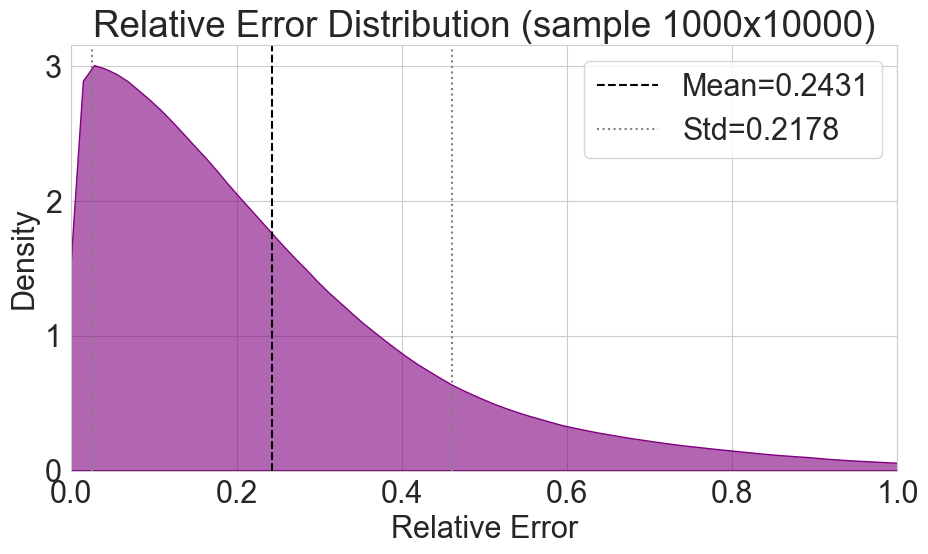

[cdist] sample 1000 queries x 10000 DB: 0.557s
Mean relative error=0.243077, Std=0.217795


In [103]:
import matplotlib.pyplot as plt 
import seaborn as sns 

plt.rcParams['font.family'] = 'serif'
sns.set_style("whitegrid")
# Relative errors
rel_error = np.abs(adc_pair_dists - exact_dists) / (exact_dists + 1e-12)
rel_error.astype(np.float32).tofile(f'{results_fp}qinco2/rel_error_pair_dec.bin')
mean_rel, std_rel = rel_error.mean(), rel_error.std()

# Plot KDE of relative errors
rel_error_flat = rel_error.ravel()
plt.figure(figsize=(10, 6))
plt.xlim(0, 1)
sns.kdeplot(rel_error_flat, fill=True, color="purple", alpha=0.6)
plt.axvline(mean_rel, linestyle="--", color="black", label=f"Mean={mean_rel:.4f}")
plt.axvline(mean_rel-std_rel, linestyle=":", color="grey")
plt.axvline(mean_rel+std_rel, linestyle=":", color="grey", label=f"Std={std_rel:.4f}")
plt.title(f"Relative Error Distribution (sample {len(q_idx)}x{len(db_idx)})")
plt.xlabel("Relative Error")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

print(f"[cdist] sample {len(q_idx)} queries x {len(db_idx)} DB: {cdist_time:.3f}s")
print(f"Mean relative error={mean_rel:.6f}, Std={std_rel:.6f}")


In [66]:
expe.qinco_model

{'epoch': 17,
 'model': OrderedDict([('data_mean',
               tensor([ 0.6408, -0.3002, -0.5172,  0.6420, -0.2236,  0.0126,  0.2632,  0.1999,
                        0.0883,  0.0387,  0.1618, -0.0167,  0.4874, -0.3517, -0.2533, -0.1558,
                        0.2367, -0.0015, -0.0265,  0.2092,  0.1074,  0.2435, -0.0491, -0.1593,
                        0.3985, -0.0589, -0.4594,  0.2817, -0.0862,  0.4469, -0.0210,  0.1782,
                       -0.3626,  0.1282, -0.0328,  0.4762, -0.3422, -0.1390, -0.3800,  0.0746,
                        0.5322,  0.5719, -0.5769, -0.4046, -0.0866, -0.0187, -0.1297,  0.1136,
                        0.0938, -0.2832,  0.2113, -0.1639, -0.3222, -0.1793,  0.1658, -0.0597,
                       -0.0031, -0.4039,  0.2290,  0.1931,  0.0752,  0.1785, -0.2347, -0.1792,
                        0.0117, -0.1481, -0.0977,  0.1194,  0.1368, -0.5318, -0.2585,  0.1938,
                        0.0443, -0.4083,  0.0072,  0.2018,  0.0287,  0.2736,  0.1001, -0.1730,